In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")

In [5]:
df.columns = df.columns.str.strip()
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)
df.shape

(2827876, 80)

In [6]:
X = df.drop(["Label", "is_attack"], axis=1)
y= df["is_attack"]

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[412831  41434]
 [  4314 106997]]
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    454265
           1       0.72      0.96      0.82    111311

    accuracy                           0.92    565576
   macro avg       0.86      0.94      0.89    565576
weighted avg       0.94      0.92      0.92    565576



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [13]:
y_pred_rf = rf_model.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[453985    280]
 [   296 111015]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       1.00      1.00      1.00    111311

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576



In [15]:
X.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [16]:
y_train_pred = rf_model.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1817055
           1       1.00      1.00      1.00    445245

    accuracy                           1.00   2262300
   macro avg       1.00      1.00      1.00   2262300
weighted avg       1.00      1.00      1.00   2262300



In [17]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       0.99      1.00      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      1.00      0.99    565576
weighted avg       1.00      1.00      1.00    565576



#### shuffle test

In [18]:
y_train_shuffled = y_train.sample(frac=1, random_state=42).reset_index(drop=True)

rf_test = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_test.fit(X_train, y_train_shuffled)

y_pred_shuffled = rf_test.predict(X_test)

print(classification_report(y_test, y_pred_shuffled))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86    454265
           1       0.28      0.13      0.17    111311

    accuracy                           0.76    565576
   macro avg       0.54      0.52      0.52    565576
weighted avg       0.71      0.76      0.73    565576



#### Feature Importance

In [19]:
import pandas as pd

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
feature_importances.head(15)

Max Packet Length          0.084713
Init_Win_bytes_forward     0.063519
Average Packet Size        0.054500
Destination Port           0.051083
Min Packet Length          0.050912
Bwd Packet Length Std      0.046613
Packet Length Variance     0.045756
Packet Length Std          0.041832
Init_Win_bytes_backward    0.041091
Fwd Packet Length Mean     0.039806
Bwd Packet Length Max      0.032063
Fwd Packet Length Max      0.027652
Avg Bwd Segment Size       0.027093
Bwd Packet Length Min      0.023610
Subflow Fwd Bytes          0.023539
dtype: float64

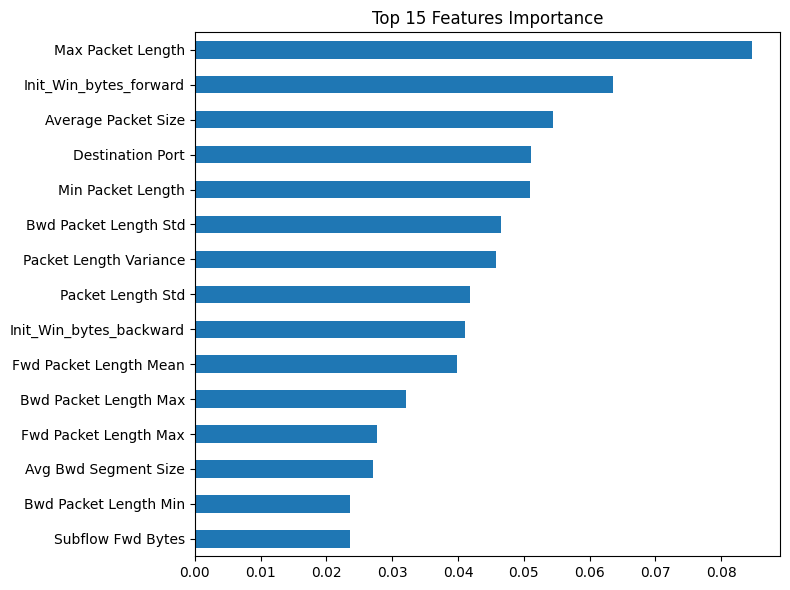

In [20]:
import matplotlib.pyplot as plt

top15 = feature_importances.head(15)

plt.figure(figsize=(8,6))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 Features Importance")
plt.tight_layout()
plt.show()




In [21]:
# model karşılaştırma


In [22]:
from sklearn.metrics import classification_report
import pandas as pd

report_log = classification_report(y_test, y_pred, output_dict=True)

report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision (Attack)": [
        report_log["1"]["precision"],
        report_rf["1"]["precision"]
    ],
    "Recall (Attack)": [
        report_log["1"]["recall"],
        report_rf["1"]["recall"]
    ],
    "F1 (Attack)": [
        report_log["1"]["f1-score"],
        report_rf["1"]["f1-score"]
    ]
})

comparison

,Model,Precision (Attack),Recall (Attack),F1 (Attack)
0,Logistic Regression,0.720853,0.961244,0.823871
1,Random Forest,0.985085,0.996245,0.990634


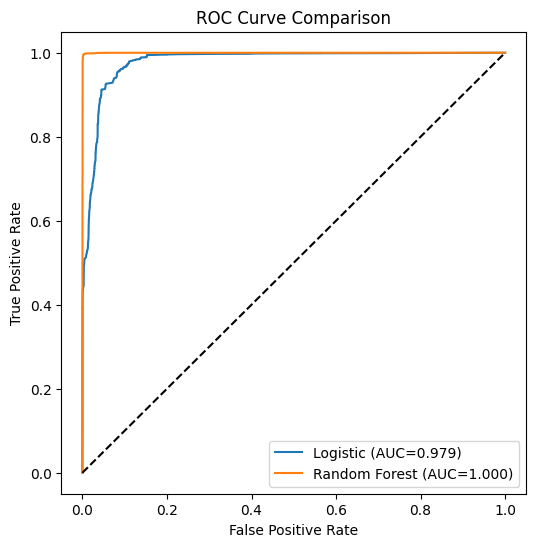

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic probability
y_prob_log = model.predict_proba(X_test_scaled)[:, 1]
# RF probability
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

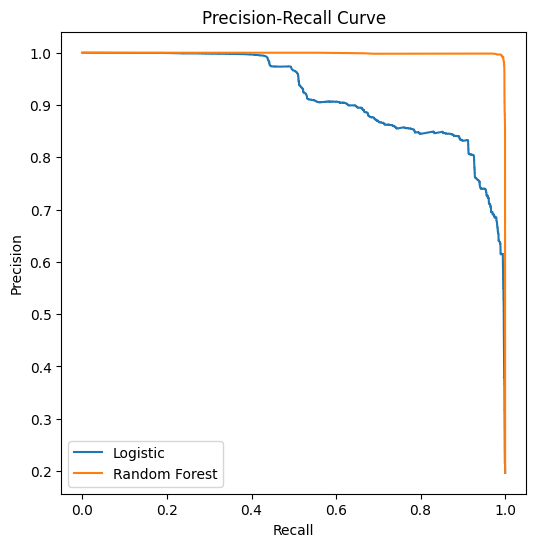

In [24]:
from sklearn.metrics import precision_recall_curve, auc

precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,6))
plt.plot(recall_log, precision_log, label="Logistic")
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()